In [1]:
import os
import json

from itertools import chain
from tqdm import tqdm
import numpy as np
import pandas as pd
import nibabel as nib
import cv2
from skimage import morphology, filters, measure
import SimpleITK as sitk
from scipy.ndimage import binary_erosion, binary_dilation

import matplotlib.pyplot as plt


In [2]:
NYUL_MIN_VALUE = 0
NYUL_MAX_VALUE = 255
NYUL_MIN_PERCENTILE = 1
NYUL_MAX_PERCENTILE = 99

# list_pelvis_image_dir = [os.path.join(DIR_PELVIS, f) for f in os.listdir(DIR_PELVIS) if f.startswith("1P")]

DELTA=250
THRESH_MR_MASK = 15


def load_nifti_image(image_path):
    img = nib.load(image_path)
    return img.get_fdata()

def apply_mask(mr_image, mask):
    if mr_image.shape != mask.shape:
        raise ValueError(f"Unmatched Image and shape {mr_image.shape} vs {mask.shape}")
    return mr_image * (mask > 0).astype(mr_image.dtype)

def center_pad_to_square_by_slice(image):
    if len(image.shape) == 2:
        return center_pad_single_slice(image)
    elif len(image.shape) == 3:
        h, w, num_slices = image.shape
        max_size = max(h, w)
        square_volume = np.zeros((max_size, max_size, num_slices), dtype=image.dtype)

        for slice_idx in range(num_slices):
            current_slice = image[:, :, slice_idx]
            square_slice = center_pad_single_slice(current_slice)
            square_volume[:, :, slice_idx] = square_slice
        return square_volume
    else:
        raise ValueError(f"Unsupported image dimensions: {image.shape}")

def center_pad_single_slice(image):
    h, w = image.shape
    max_size = max(h, w)
    
    pad_h = (max_size - h) // 2
    pad_w = (max_size - w) // 2
    
    square_slice = np.zeros((max_size, max_size), dtype=image.dtype)
    square_slice[pad_h:pad_h+h, pad_w:pad_w+w] = image

    return square_slice, (pad_h, pad_w)

def center_pad_single_slice_by_params(image, pad_h, pad_w):
    h, w = image.shape
    max_size = max(h, w)

    square_slice = np.zeros((max_size, max_size), dtype=image.dtype)
    square_slice[pad_h:pad_h+h, pad_w:pad_w+w] = image
    return square_slice

def center_pad_to_square(image):
    h, w = image.shape[:2]
    max_size = max(h, w)
    
    pad_h = (max_size - h) // 2
    pad_w = (max_size - w) // 2
    
    if len(image.shape) == 2:
        square_image = np.zeros((max_size, max_size), dtype=image.dtype)
        square_image[pad_h:pad_h+h, pad_w:pad_w+w] = image
    else:
        square_image = np.zeros((max_size, max_size, image.shape[2]), dtype=image.dtype)
        square_image[pad_h:pad_h+h, pad_w:pad_w+w, :] = image
    
    return square_image

def resize_image(image, target_size=[240, 240]):
    """Resize the image to the target size."""
    return cv2.resize(image, target_size, interpolation=cv2.INTER_NEAREST_EXACT)


def n4_bias_correction(image, mask):
    image = ants.from_numpy(image.astype(np.float32, copy=False))
    mask = ants.from_numpy(mask.astype(np.float32, copy=False))
    return ants.n4_bias_field_correction(
        image=image,
        mask=mask,
        shrink_factor=3,
        spline_param=[100, 100, 120],
        convergence={"iters": [50, 50, 20], "tol": 1e-3},
        verbose=False,
    )

def minmax_normalize_numpy(volume, clip_range=(0, 2000)):
    v = volume.astype(np.float32)
    v = v.clip(*clip_range)
    v_min, v_max = np.min(v), np.max(v)
    if v_max > v_min:  # avoid divide by zero
        v = (v - v_min) / (v_max - v_min) * 255
    else:
        v = np.zeros_like(v)
    return v.astype(np.uint8)

In [3]:
class MetalArtifactDetector:
    def __init__(self, metric='f1'):
        """
        metric: ('f1', 'youden', 'balanced_acc', 'recall', 'precision', 'accuracy')
        """
        self.metric = metric
        self.tau_global = None
        self.tau_map = {}

    @staticmethod
    def _confusion_binary(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.uint8)
        y_pred = np.asarray(y_pred, dtype=np.uint8)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        return tp, fp, fn, tn

    @staticmethod
    def _metrics_from_cm(tp, fp, fn, tn, eps=1e-9):
        prec = tp / (tp + fp + eps)
        rec  = tp / (tp + fn + eps)
        f1   = 2 * prec * rec / (prec + rec + eps)
        tpr  = rec
        tnr  = tn / (tn + fp + eps)
        bal_acc = 0.5 * (tpr + tnr)
        youden  = tpr + tnr - 1.0
        acc     = (tp + tn) / (tp + fp + fn + tn + eps)
        return {
            "precision": prec, "recall": rec, "f1": f1,
            "balanced_acc": bal_acc, "youden": youden, "accuracy": acc
        }

    @staticmethod
    def _norm01(x, hu_window=None, clip_quantiles=None, eps=1e-6):
        x = np.asarray(x, dtype=float)
        if hu_window is not None:
            lo, hi = hu_window
            x = np.clip(x, lo, hi)
        elif clip_quantiles is not None:
            qlo, qhi = clip_quantiles
            lo = np.percentile(x, qlo*100.0)
            hi = np.percentile(x, qhi*100.0)
            x = np.clip(x, lo, hi)
        mn, mx = x.min(), x.max()
        if mx - mn < eps:
            return np.zeros_like(x)
        return (x - mn) / (mx - mn + eps)

    def score_volume_hu(self, vol, scan_id="scan1", slice_axis=0):
        """return max HU for each slice"""
        vol_z = np.moveaxis(vol, slice_axis, 0)  # (Z,H,W)
        z, h, w = vol_z.shape
        slice_max = np.max(vol_z.reshape(z, -1), axis=1)
        return pd.DataFrame({
            "scan_id": scan_id,
            "slice_idx": np.arange(z),
            "slice_max_hu": slice_max.astype(float),
        })

    def pick_global_tau_by_hu(self, df, metal_slices=None,
                              label_col='label', hu_col='slice_max_hu'):
        """
        global_tau = max(max_normal_hu, min_max_abnormal_hu)
        """
        if metal_slices is None:
            if label_col not in df.columns:
                raise ValueError("Need metal_slices or df[label_col].")
            labels = df[label_col].values.astype(int)
            pos_idx = np.where(labels == 1)[0]
            neg_idx = np.where(labels == 0)[0]
        else:
            sl = df["slice_idx"].values
            pos_mask = np.isin(sl, np.asarray(metal_slices, dtype=int))
            pos_idx = np.where(pos_mask)[0]
            neg_idx = np.where(~pos_mask)[0]

        vals = df[hu_col].values.astype(float)

        max_normal_hu = float(vals[neg_idx].max()) if len(neg_idx) > 0 else -np.inf
        min_max_abnormal_hu = float(vals[pos_idx].min()) if len(pos_idx) > 0 else np.inf

        global_tau = max(max_normal_hu, min_max_abnormal_hu)
        self.tau_global = global_tau
        return global_tau, {
            "max_normal_hu": max_normal_hu,
            "min_max_abnormal_hu": min_max_abnormal_hu
        }

    def apply_tau_by_hu(self, df, hu_col='slice_max_hu'):
        """classify slices based on HU values"""
        if self.tau_global is None or not np.isfinite(self.tau_global):
            raise ValueError("Global tau not set. Run pick_global_tau_by_hu first.")
        out = df.copy()
        out["pred"] = (out[hu_col].values >= self.tau_global).astype(np.uint8)
        return out

    def evaluate(self, df, label_col='label', pred_col='pred', scan_col='scan_id'):
        # slice-level
        tp, fp, fn, tn = self._confusion_binary(df[label_col].values, df[pred_col].values)
        sl = self._metrics_from_cm(tp, fp, fn, tn)
        sl.update(dict(tp=tp, fp=fp, fn=fn, tn=tn))

        # scan-level
        scan_true = df.groupby(scan_col, sort=False)[label_col].max().values
        scan_pred = df.groupby(scan_col, sort=False)[pred_col].max().values
        tp, fp, fn, tn = self._confusion_binary(scan_true, scan_pred)
        sc = self._metrics_from_cm(tp, fp, fn, tn)
        sc.update(dict(tp=tp, fp=fp, fn=fn, tn=tn))
        return {"slice_level": sl, "scan_level": sc}


    def extract_mask_volume(self, vol, tau, slice_axis=0):
        return (vol >= tau).astype(np.uint8)

    def postprocess_mask(self, mask2d, min_hole_size=20, smooth=True, disk_size=3):
        mask = mask2d.astype(bool)

        mask = morphology.remove_small_holes(mask, area_threshold=min_hole_size)

        if smooth:
            selem = morphology.disk(disk_size)
            mask = morphology.binary_opening(mask, selem)
            mask = morphology.binary_closing(mask, selem)

        return mask.astype(np.uint8)

    def postprocess_mask_volume(self, mask_vol, slice_axis=0,
                                min_hole_size=20, smooth=True, disk_size=0):
        vol_z = np.moveaxis(mask_vol, slice_axis, 0)
        out_z = []
        for z in range(vol_z.shape[0]):
            out_z.append(self.postprocess_mask(vol_z[z],
                                               min_hole_size=min_hole_size,
                                               smooth=smooth,
                                               disk_size=disk_size))
        out = np.stack(out_z, axis=0)
        return np.moveaxis(out, 0, slice_axis)
    
    def show_ct_mask_mr(
        self, ct_vol, mr_vol, raw_mask_vol, post_mask_vol, slice_indices,
        body_mask = None,
        slice_axis=0, suptitle="CT (raw vs postprocessed mask) & MR",
        ct_hu_window=None, ct_clip_quantiles=None,
        mr_clip_quantiles=None,
        fill_alpha=0.6, outline_width=1.5,
        raw_color=(0.0, 0, 1.0),   # blue
        post_color=(0.0, 1.0, 0.0), # green
        outline_color="red",
        figsize=(12, 3)
    ):
        if isinstance(slice_indices, int):
            slice_indices = [slice_indices]

        ct = np.moveaxis(ct_vol, slice_axis, 0)
        mr = np.moveaxis(mr_vol, slice_axis, 0)
        if body_mask is not None:
            # ValueError: operands could not be broadcast together with shapes (149,428,277) (428,277,149) 
            mr = mr * np.moveaxis(body_mask, slice_axis, 0)

        raw_mask = np.moveaxis(raw_mask_vol, slice_axis, 0)
        post_mask = np.moveaxis(post_mask_vol, slice_axis, 0)

        print(ct.shape, mr.shape, raw_mask.shape, post_mask.shape)
        assert ct.shape == mr.shape == raw_mask.shape == post_mask.shape, "Shapes must match"

        n = len(slice_indices)
        fig, axs = plt.subplots(n, 3, figsize=(figsize[0], figsize[1] * n))

        if n == 1:
            axs = np.expand_dims(axs, 0)

        for i, z in enumerate(slice_indices):
            ct_img = self._norm01(ct[z], hu_window=ct_hu_window, clip_quantiles=ct_clip_quantiles)
            mr_img = self._norm01(mr[z], clip_quantiles=mr_clip_quantiles)
            raw_mask_img = raw_mask[z].astype(bool)
            post_mask_img = post_mask[z].astype(bool)

            ct_img  = np.rot90(ct_img,  k=-1)
            mr_img  = np.rot90(mr_img,  k=-1)
            raw_mask_img  = np.rot90(raw_mask_img,  k=-1)
            post_mask_img = np.rot90(post_mask_img, k=-1)

            # CT + raw mask
            axs[i, 0].imshow(ct_img, cmap="gray")
            overlay_raw = np.zeros((*raw_mask_img.shape, 4), dtype=float)
            r, g, b = raw_color
            overlay_raw[raw_mask_img] = [r, g, b, float(fill_alpha)]
            axs[i, 0].imshow(overlay_raw)
            contours = measure.find_contours(raw_mask_img, level=0.5)
            for contour in contours:
                axs[i, 0].plot(contour[:, 1], contour[:, 0], color=outline_color, linewidth=outline_width)
            axs[i, 0].set_title(f"Raw Mask+CT z={z}")
            axs[i, 0].axis("off")

            # CT + postprocessed mask
            axs[i, 1].imshow(ct_img, cmap="gray")
            overlay_post = np.zeros((*post_mask_img.shape, 4), dtype=float)
            r, g, b = post_color
            overlay_post[post_mask_img] = [r, g, b, float(fill_alpha)]
            axs[i, 1].imshow(overlay_post)
            contours = measure.find_contours(post_mask_img, level=0.5)
            for contour in contours:
                axs[i, 1].plot(contour[:, 1], contour[:, 0], color=outline_color, linewidth=outline_width)
            axs[i, 1].set_title(f"Post Mask+CT z={z}")
            axs[i, 1].axis("off")

            # MR
            axs[i, 2].imshow(mr_img, cmap="gray")
            axs[i, 2].set_title(f"MR z={z}")
            axs[i, 2].axis("off")

        plt.suptitle(suptitle, fontsize=14)
        plt.tight_layout()
        plt.show()

    def get_mask_biggest_contour(self, mask_ct):
        for i in range(mask_ct.shape[2]):
            inmask = np.expand_dims(mask_ct[:, :, i].astype(np.uint8), axis=2)
            ret, bin_img = cv2.threshold(inmask, 0.5, 1, cv2.THRESH_BINARY)
            (cnts, _) = cv2.findContours(np.expand_dims(bin_img, axis=2), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            # return None, if no contours detected
            if len(cnts) != 0:
                # based on contour area, get the maximum contour which is a body contour
                segmented = max(cnts, key=cv2.contourArea)
                bin_img[bin_img > 0] = 0
                a = cv2.drawContours(np.expand_dims(bin_img, axis=2), [segmented], 0, (255, 255, 255), -1)
                a[a > 0] = 1
                mask_ct[:, :, i] = a.squeeze()
        return mask_ct.astype(np.uint8)

    def get_body_mask_threshold(self, nii_array, threshold_ct_body_mask):
        mask_ct = np.zeros(nii_array.shape)
        mask_ct[nii_array > threshold_ct_body_mask] = 1
        mask_ct[nii_array <= threshold_ct_body_mask] = 0
        mask_ct = binary_erosion(mask_ct, iterations=2).astype(np.uint8)
        mask_ct = self.get_mask_biggest_contour(mask_ct)
        mask_ct = binary_dilation(mask_ct, iterations=5).astype(np.int16)
        return mask_ct
    
    
    def refine_mask_with_mr(self, ct_mask_vol, mr_vol, lo_diff=10, up_diff=150, min_contour_area=5, max_intensity_threshold=50):
        """
        Refines a 3D CT mask volume using a corresponding MR volume by performing
        a flood-fill operation on each slice. Handles small, single-pixel anomalies
        by preserving the original CT mask.

        Args:
            ct_mask_vol (np.ndarray): The 3D volume of the initial CT masks (binary, uint8).
            mr_vol (np.ndarray): The 3D volume of the MR images.
            lo_diff (int): The lower boundary difference from the seed pixel's value.
            up_diff (int): The upper boundary difference from the seed pixel's value.
                           These values determine the sensitivity to gradient changes.
            min_contour_area (int): The minimum area of a contour to trigger the flood fill.
                                    If a contour is smaller than this, the original mask is used.
            max_intensity_threshold (int): The maximum mean intensity within a contour to trigger the flood fill.
                                            If the mean intensity is higher than this, the original mask is used.

        Returns:
            np.ndarray: The refined 3D mask volume (binary, uint8).
        """
        assert ct_mask_vol.shape == mr_vol.shape, "CT mask and MR must have the same shape"
        
        # Create an empty volume to store the refined masks
        refined_mask = np.zeros_like(ct_mask_vol, dtype=np.uint8)

        # Iterate over each slice in the 3D volumes
        for i in range(ct_mask_vol.shape[2]):
            slice_ct = ct_mask_vol[:, :, i].astype(np.uint8)
            slice_mr = mr_vol[:, :, i]

            # If there's no mask on this slice, skip it
            if slice_ct.sum() == 0:
                continue

            # Find all contours on this slice
            contours, _ = cv2.findContours(slice_ct, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if not contours:
                continue

            # This will store the combined result of all flood fills and preserved masks
            refined_mask_slice = np.zeros_like(slice_ct)

            for cnt in contours:
                contour_area = cv2.contourArea(cnt)

                # Create a mask for this contour
                mask_cnt = np.zeros(slice_ct.shape, dtype=np.uint8)
                cv2.drawContours(mask_cnt, [cnt], -1, 1, -1)

                # Compute mean MR intensity inside the contour
                mean_intensity = slice_mr[mask_cnt == 1].mean()

                
                # Check if the contour is too small OR if intensity is too high
                if  contour_area < min_contour_area or mean_intensity > max_intensity_threshold:
                    refined_mask_slice = np.logical_or(refined_mask_slice, mask_cnt).astype(np.uint8)
                    continue

                # Calculate the centroid (x, y) coordinates for this contour
                M = cv2.moments(cnt)
                if M["m00"] == 0:
                    continue
                
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
                # --- Perform the flood-fill operation for this specific contour ---
                flood_fill_slice = slice_mr.copy().astype(np.float32)

                # Create an empty mask to store the result of the flood fill.
                h, w = flood_fill_slice.shape
                mask = np.zeros((h + 2, w + 2), np.uint8)

                cv2.floodFill(flood_fill_slice, mask, (cx, cy), 255, lo_diff, up_diff, cv2.FLOODFILL_MASK_ONLY)

                # Remove the extra border from the mask to get the final refined mask for the slice.
                current_fill = mask[1:-1, 1:-1]
                                
                # Combine the new flood fill result with the existing refined mask for the slice
                refined_mask_slice = np.logical_or(refined_mask_slice, current_fill).astype(np.uint8)

            refined_mask[:, :, i] = refined_mask_slice

        return refined_mask

Testing New MASK

In [4]:
import cv2
import numpy as np
from skimage import measure

def postprocess_mask_morph(mask2d, disk_size=3, min_area_for_smooth=50):
    """
    Morphological postprocessing for binary masks with conditional smoothing
    based on anomaly area.

    Args:
        mask2d (np.ndarray): 2D binary mask.
        disk_size (int): Kernel size for morphological operations.
        smooth (bool): Apply smoothing if True.
        min_area_for_smooth (int): Minimum anomaly area to apply smoothing.

    Returns:
        np.ndarray: Postprocessed binary mask (0/1).
    """
    mask = mask2d.astype(np.uint8)
    
    # Compute total anomaly area in this slice
    total_area = np.count_nonzero(mask)
    
    # Only apply smoothing if the total area exceeds threshold
    if total_area >= min_area_for_smooth:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask.astype(np.uint8)


def postprocess_mask_volume_morph(mask_vol, slice_axis=0,
                                   disk_size=3, min_area_for_smooth=50):
    """
    Apply conditional morphological postprocessing slice-by-slice.
    """
    vol = np.moveaxis(mask_vol, slice_axis, 0)
    out_slices = []
    for z in range(vol.shape[0]):
        out_slices.append(postprocess_mask_morph(
            vol[z],
            disk_size=disk_size,
            min_area_for_smooth=min_area_for_smooth
        ))
    out_vol = np.stack(out_slices, axis=0)
    return np.moveaxis(out_vol, 0, slice_axis)


Using tau = 2000


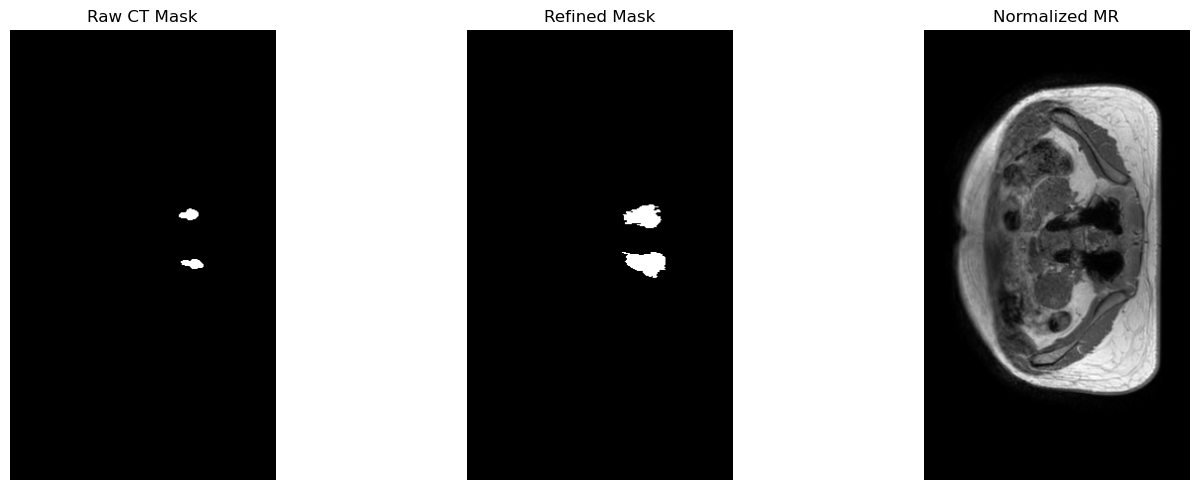

In [24]:
dir_scan = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA136'
path_mr = os.path.join(dir_scan, "mr.nii.gz")
path_mask = os.path.join(dir_scan, "mask.nii.gz")
path_ct = os.path.join(dir_scan, "ct.nii.gz")

# Load data with spacing
mr_image = load_nifti_image(path_mr)
ct_image = load_nifti_image(path_ct)
mask = load_nifti_image(path_mask)

# Init detector
det = MetalArtifactDetector()

# Body mask (rough background removal)
THRESH_MR_MASK = 0.1
body_mask = det.get_body_mask_threshold(mr_image * mask, threshold_ct_body_mask=THRESH_MR_MASK)
body_mask = np.logical_and(body_mask > 0, mask > 0)

# Masked + normalized MR
masked_mr = apply_mask(mr_image, body_mask)
mr_normalized = minmax_normalize_numpy(masked_mr)

# Changed to simple thresholding on CT for testing
tau = 2000
print("Using tau =", tau)
mask_vol_ct = (ct_image >= tau).astype(np.uint8)

# This code is needed for the new mask refinement
# Refine with MR
lo_diff_val = 5
up_diff_val = 15
mask_vol_refined = det.refine_mask_with_mr(mask_vol_ct, mr_image, lo_diff=lo_diff_val, up_diff=up_diff_val)
mask_vol_refined = postprocess_mask_volume_morph(mask_vol_refined, disk_size=5, min_area_for_smooth=50, slice_axis=0)

# Choose the slice index you want to visualize
slice_idx = 110

# Create a 1x3 subplot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Raw CT mask
axs[0].imshow(mask_vol_ct[:, :, slice_idx], cmap="gray")
axs[0].set_title("Raw CT Mask")
axs[0].axis("off")

# Refined mask
axs[1].imshow(mask_vol_refined[:, :, slice_idx], cmap="gray")
axs[1].set_title("Refined Mask")
axs[1].axis("off")

# Normalized MR
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray")
axs[2].set_title("Normalized MR")
axs[2].axis("off")

plt.tight_layout()
plt.show()

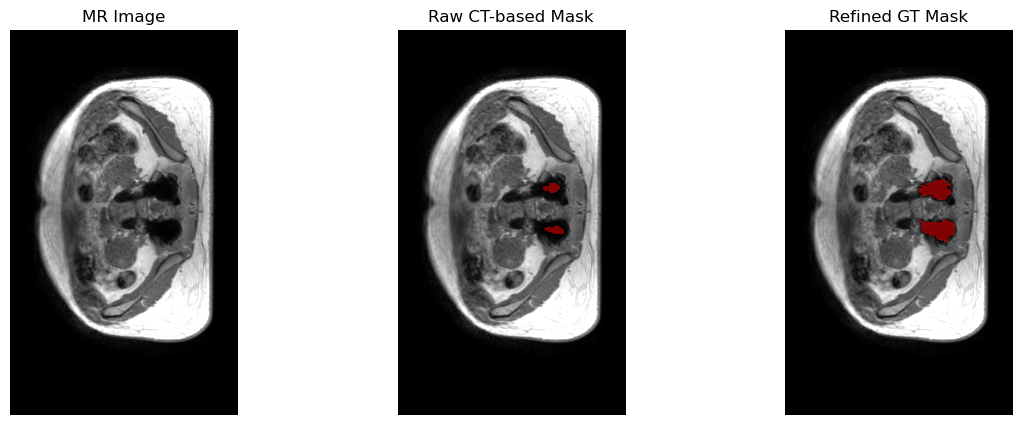

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba

# Compute intensity limits for good MR contrast
finite = np.isfinite(mr_normalized)
if finite.any():
    vmin, vmax = np.percentile(mr_normalized[finite], [2, 98])
else:
    vmin, vmax = None, None

red_overlay = ListedColormap([to_rgba("red")])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax in axs:
    ax.axis("off")

# MR only
axs[0].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[0].set_title("MR Image")

# MR + Raw CT mask
axs[1].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[1].imshow(
    np.ma.masked_where(mask_vol_ct[:, :, slice_idx] == 0, mask_vol_ct[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[1].set_title("Raw CT-based Mask")

# MR + Refined mask
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[2].imshow(
    np.ma.masked_where(mask_vol_refined[:, :, slice_idx] == 0, mask_vol_refined[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Refined GT Mask")


plt.subplots_adjust(wspace=0.00)
plt.show()


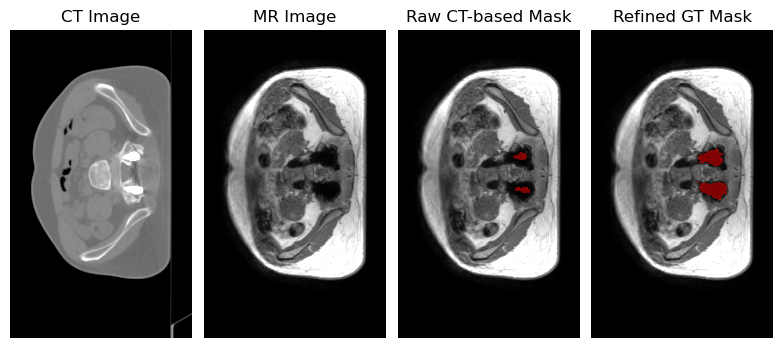

In [40]:
# Choose the slice index you want to visualize
slice_idx = 110

# Compute intensity limits for good MR contrast
finite_mr = np.isfinite(mr_normalized)
if finite_mr.any():
    vmin_mr, vmax_mr = np.percentile(mr_normalized[finite_mr], [2, 98])
else:
    vmin_mr, vmax_mr = None, None

# CT windowing: a bit narrower around soft tissue
ct_center = 0     # around water
ct_width  = 1500   # wide window

vmin_ct = ct_center - ct_width / 2   # -400
vmax_ct = ct_center + ct_width / 2   #  400


fig, axs = plt.subplots(1, 4, figsize=(10, 4))
for ax in axs:
    ax.axis("off")

# CT with windowing
axs[0].imshow(ct_image[:, :, slice_idx], cmap="gray",
              vmin=vmin_ct, vmax=vmax_ct)
axs[0].set_title("CT Image")

# MR
axs[1].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[1].set_title("MR Image")

# MR + raw mask
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[2].imshow(
    np.ma.masked_where(mask_vol_ct[:, :, slice_idx] == 0,
                       mask_vol_ct[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Raw CT-based Mask")

# MR + refined mask
axs[3].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[3].imshow(
    np.ma.masked_where(mask_vol_refined[:, :, slice_idx] == 0,
                       mask_vol_refined[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[3].set_title("Refined GT Mask")


plt.subplots_adjust(wspace=0.00)
plt.savefig('refined_mask_comparison_2.pdf', bbox_inches='tight')
plt.show()

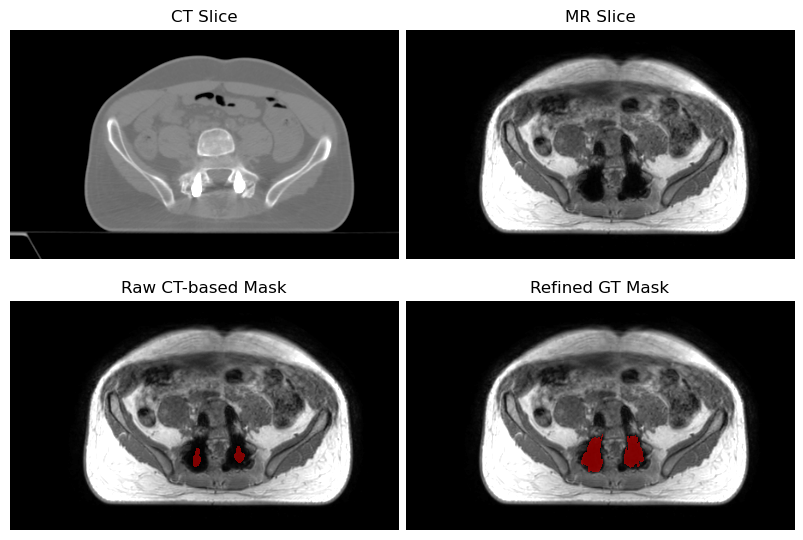

In [27]:
# Choose the slice index you want to visualize
slice_idx = 110

# Helper: rotate 2D slice 90° clockwise
def rot(slice2d):
    return np.rot90(slice2d, k=-1)

# Compute intensity limits for good MR contrast
finite_mr = np.isfinite(mr_normalized)
if finite_mr.any():
    vmin_mr, vmax_mr = np.percentile(mr_normalized[finite_mr], [2, 98])
else:
    vmin_mr, vmax_mr = None, None

# CT windowing: a bit narrower around soft tissue
ct_center = 0      # around water
ct_width  = 1500   # wide window

vmin_ct = ct_center - ct_width / 2
vmax_ct = ct_center + ct_width / 2

# 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# CT with windowing (rotated)
axs[0].imshow(rot(ct_image[:, :, slice_idx]), cmap="gray",
              vmin=vmin_ct, vmax=vmax_ct)
axs[0].set_title("CT Slice")

# MR (rotated)
axs[1].imshow(rot(mr_normalized[:, :, slice_idx]), cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[1].set_title("MR Slice")

# MR + raw mask (rotated)
mr_slice_rot = rot(mr_normalized[:, :, slice_idx])
raw_mask_rot = rot(mask_vol_ct[:, :, slice_idx])

axs[2].imshow(mr_slice_rot, cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[2].imshow(
    np.ma.masked_where(raw_mask_rot == 0, raw_mask_rot),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Raw CT-based Mask")

# MR + refined mask (rotated)
refined_mask_rot = rot(mask_vol_refined[:, :, slice_idx])

axs[3].imshow(mr_slice_rot, cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[3].imshow(
    np.ma.masked_where(refined_mask_rot == 0, refined_mask_rot),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[3].set_title("Refined GT Mask")

plt.subplots_adjust(
    left=0.01, right=0.99,
    top=0.95, bottom=0.05,
    wspace=0.02,    # horizontal space
    hspace=0.01     # vertical space between rows (make this very small)
)
plt.savefig('refined_mask_comparison_2.pdf', bbox_inches='tight')
plt.show()


Using tau = 2575


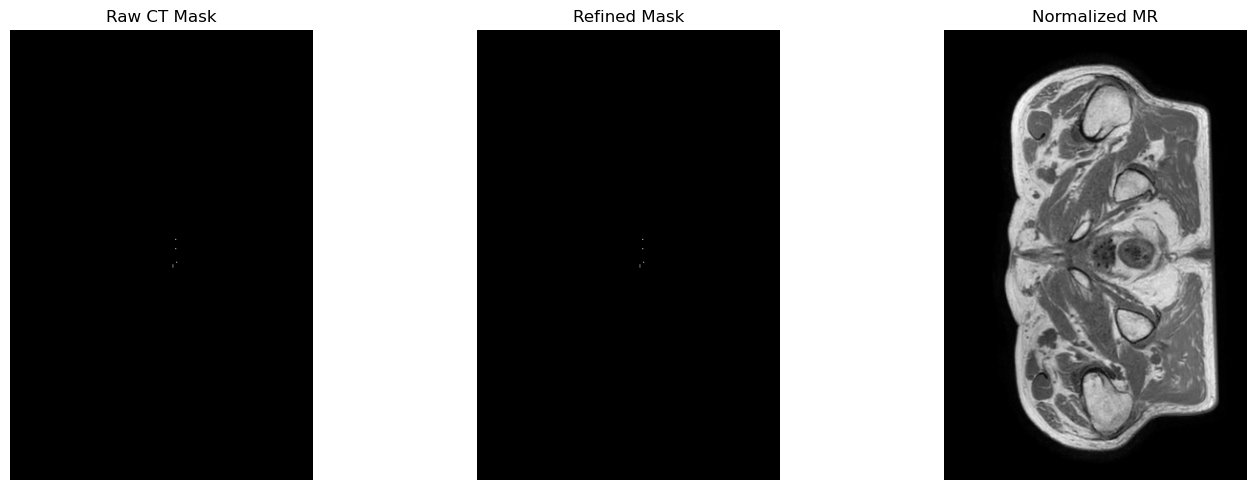

In [5]:
dir_scan = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA151'
path_mr = os.path.join(dir_scan, "mr.nii.gz")
path_mask = os.path.join(dir_scan, "mask.nii.gz")
path_ct = os.path.join(dir_scan, "ct.nii.gz")

# Load data with spacing
mr_image = load_nifti_image(path_mr)
ct_image = load_nifti_image(path_ct)
mask = load_nifti_image(path_mask)

# Init detector
det = MetalArtifactDetector()

# Body mask (rough background removal)
THRESH_MR_MASK = 0.1
body_mask = det.get_body_mask_threshold(mr_image * mask, threshold_ct_body_mask=THRESH_MR_MASK)
body_mask = np.logical_and(body_mask > 0, mask > 0)

# Masked + normalized MR
masked_mr = apply_mask(mr_image, body_mask)
mr_normalized = minmax_normalize_numpy(masked_mr)

# Changed to simple thresholding on CT for testing
tau = 2575
print("Using tau =", tau)
mask_vol_ct = (ct_image >= tau).astype(np.uint8)

# This code is needed for the new mask refinement
# Refine with MR
lo_diff_val = 5
up_diff_val = 15
mask_vol_refined = det.refine_mask_with_mr(mask_vol_ct, mr_image, lo_diff=lo_diff_val, up_diff=up_diff_val)
mask_vol_refined = postprocess_mask_volume_morph(mask_vol_refined, disk_size=5, min_area_for_smooth=50, slice_axis=0)

# Choose the slice index you want to visualize
slice_idx = 48

# Create a 1x3 subplot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Raw CT mask
axs[0].imshow(mask_vol_ct[:, :, slice_idx], cmap="gray")
axs[0].set_title("Raw CT Mask")
axs[0].axis("off")

# Refined mask
axs[1].imshow(mask_vol_refined[:, :, slice_idx], cmap="gray")
axs[1].set_title("Refined Mask")
axs[1].axis("off")

# Normalized MR
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray")
axs[2].set_title("Normalized MR")
axs[2].axis("off")

plt.tight_layout()
plt.show()

Using tau = 600


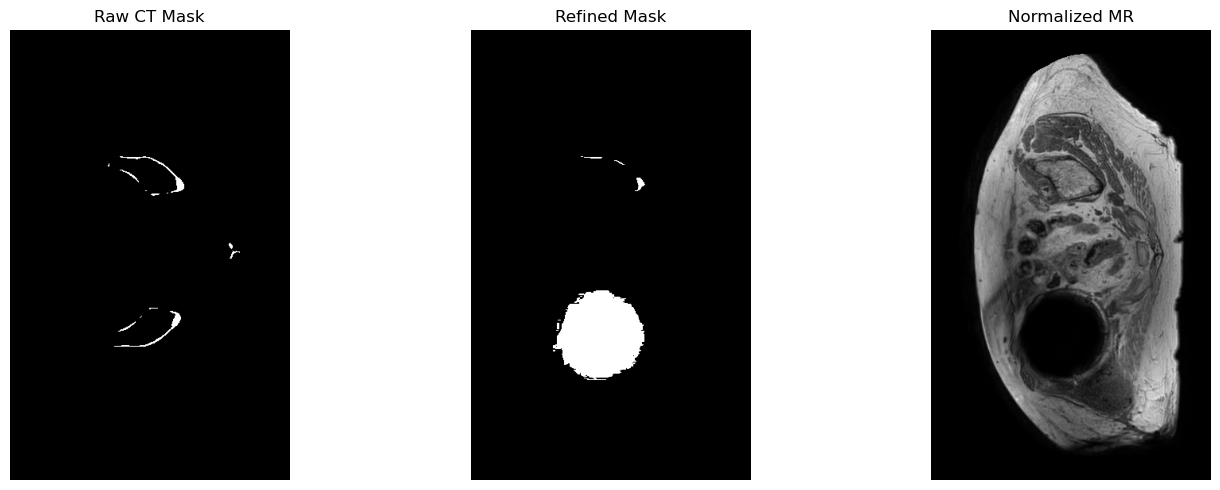

In [28]:
dir_scan = r'C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA155'
path_mr = os.path.join(dir_scan, "mr.nii.gz")
path_mask = os.path.join(dir_scan, "mask.nii.gz")
path_ct = os.path.join(dir_scan, "ct.nii.gz")

# Load data with spacing
mr_image = load_nifti_image(path_mr)
ct_image = load_nifti_image(path_ct)
mask = load_nifti_image(path_mask)

# Init detector
det = MetalArtifactDetector()

# Body mask (rough background removal)
THRESH_MR_MASK = 0.1
body_mask = det.get_body_mask_threshold(mr_image * mask, threshold_ct_body_mask=THRESH_MR_MASK)
body_mask = np.logical_and(body_mask > 0, mask > 0)

# Masked + normalized MR
masked_mr = apply_mask(mr_image, body_mask)
mr_normalized = minmax_normalize_numpy(masked_mr)

# Changed to simple thresholding on CT for testing
tau = 600
print("Using tau =", tau)
mask_vol_ct = (ct_image >= tau).astype(np.uint8)


# This code is needed for the new mask refinement
# Refine with MR
lo_diff_val = 5
up_diff_val = 15
mask_vol_refined = det.refine_mask_with_mr(mask_vol_ct, mr_image, lo_diff=lo_diff_val, up_diff=up_diff_val)
mask_vol_refined = postprocess_mask_volume_morph(mask_vol_refined, disk_size=5, min_area_for_smooth=50)


# Choose the slice index you want to visualize
slice_idx = 93

# Create a 1x3 subplot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Raw CT mask
axs[0].imshow(mask_vol_ct[:, :, slice_idx], cmap="gray")
axs[0].set_title("Raw CT Mask")
axs[0].axis("off")

# Refined mask
axs[1].imshow(mask_vol_refined[:, :, slice_idx], cmap="gray")
axs[1].set_title("Refined Mask")
axs[1].axis("off")

# Normalized MR
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray")
axs[2].set_title("Normalized MR")
axs[2].axis("off")

plt.tight_layout()
plt.show()

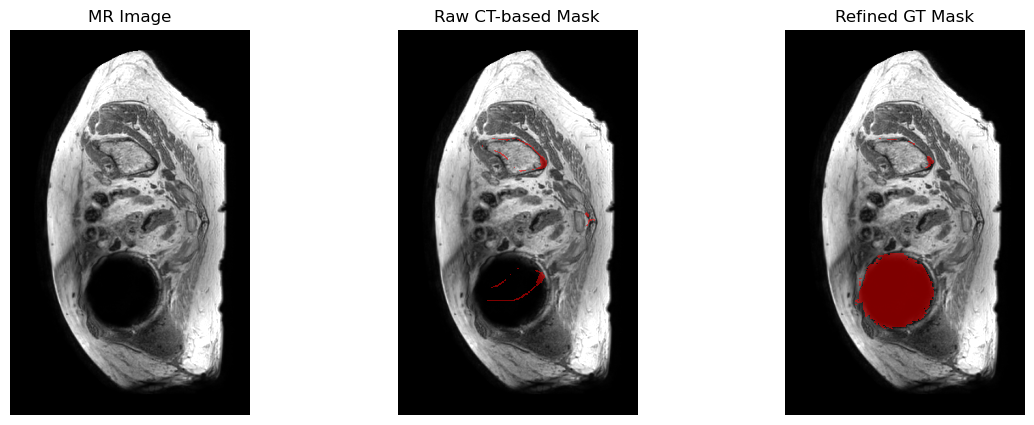

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba

# Compute intensity limits for good MR contrast
finite = np.isfinite(mr_normalized)
if finite.any():
    vmin, vmax = np.percentile(mr_normalized[finite], [2, 98])
else:
    vmin, vmax = None, None

red_overlay = ListedColormap([to_rgba("red")])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax in axs:
    ax.axis("off")

# MR only
axs[0].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[0].set_title("MR Image")

# MR + Raw CT mask
axs[1].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[1].imshow(
    np.ma.masked_where(mask_vol_ct[:, :, slice_idx] == 0, mask_vol_ct[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[1].set_title("Raw CT-based Mask")

# MR + Refined mask
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray", vmin=vmin, vmax=vmax)
axs[2].imshow(
    np.ma.masked_where(mask_vol_refined[:, :, slice_idx] == 0, mask_vol_refined[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Refined GT Mask")


plt.subplots_adjust(wspace=0.00)
plt.show()


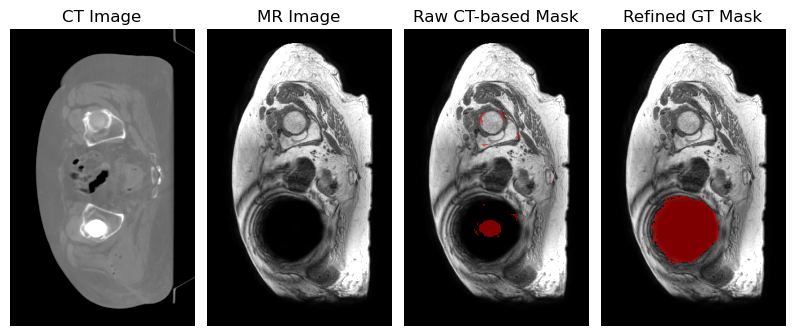

In [14]:
# Choose the slice index you want to visualize
slice_idx = 83

# Compute intensity limits for good MR contrast
finite_mr = np.isfinite(mr_normalized)
if finite_mr.any():
    vmin_mr, vmax_mr = np.percentile(mr_normalized[finite_mr], [2, 98])
else:
    vmin_mr, vmax_mr = None, None

# CT windowing: a bit narrower around soft tissue
ct_center = 0     # around water
ct_width  = 1500   # wide window

vmin_ct = ct_center - ct_width / 2   # -400
vmax_ct = ct_center + ct_width / 2   #  400


fig, axs = plt.subplots(1, 4, figsize=(10, 4))
for ax in axs:
    ax.axis("off")

# CT with windowing
axs[0].imshow(ct_image[:, :, slice_idx], cmap="gray",
              vmin=vmin_ct, vmax=vmax_ct)
axs[0].set_title("CT Image")

# MR
axs[1].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[1].set_title("MR Image")

# MR + raw mask
axs[2].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[2].imshow(
    np.ma.masked_where(mask_vol_ct[:, :, slice_idx] == 0,
                       mask_vol_ct[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Raw CT-based Mask")

# MR + refined mask
axs[3].imshow(mr_normalized[:, :, slice_idx], cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[3].imshow(
    np.ma.masked_where(mask_vol_refined[:, :, slice_idx] == 0,
                       mask_vol_refined[:, :, slice_idx]),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[3].set_title("Refined GT Mask")

plt.subplots_adjust(wspace=0.07)
#plt.savefig('refined_mask_comparison.pdf', bbox_inches='tight')
plt.show()

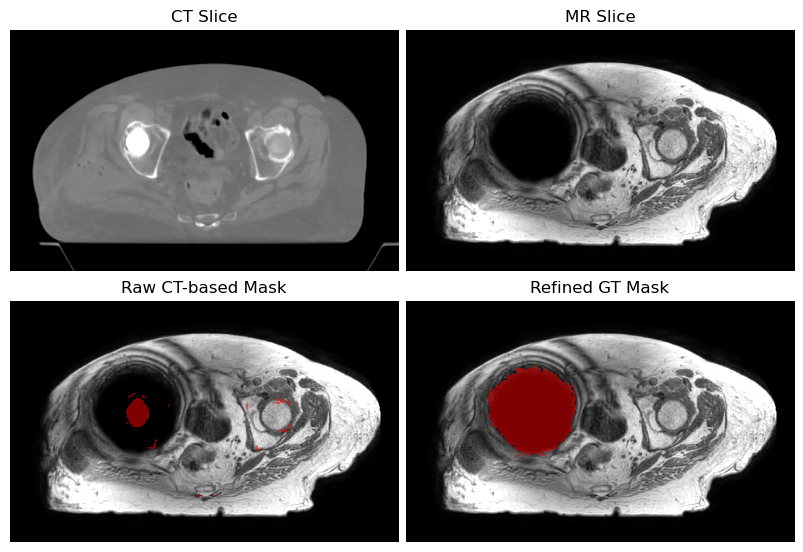

In [29]:
# Choose the slice index you want to visualize
slice_idx = 83

# Helper: rotate 2D slice 90° clockwise
def rot(slice2d):
    return np.rot90(slice2d, k=-1)

# Compute intensity limits for good MR contrast
finite_mr = np.isfinite(mr_normalized)
if finite_mr.any():
    vmin_mr, vmax_mr = np.percentile(mr_normalized[finite_mr], [2, 98])
else:
    vmin_mr, vmax_mr = None, None

# CT windowing: a bit narrower around soft tissue
ct_center = 0      # around water
ct_width  = 1500   # wide window

vmin_ct = ct_center - ct_width / 2
vmax_ct = ct_center + ct_width / 2

# 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# CT with windowing (rotated)
axs[0].imshow(rot(ct_image[:, :, slice_idx]), cmap="gray",
              vmin=vmin_ct, vmax=vmax_ct)
axs[0].set_title("CT Slice")

# MR (rotated)
axs[1].imshow(rot(mr_normalized[:, :, slice_idx]), cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[1].set_title("MR Slice")

# MR + raw mask (rotated)
mr_slice_rot = rot(mr_normalized[:, :, slice_idx])
raw_mask_rot = rot(mask_vol_ct[:, :, slice_idx])

axs[2].imshow(mr_slice_rot, cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[2].imshow(
    np.ma.masked_where(raw_mask_rot == 0, raw_mask_rot),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[2].set_title("Raw CT-based Mask")

# MR + refined mask (rotated)
refined_mask_rot = rot(mask_vol_refined[:, :, slice_idx])

axs[3].imshow(mr_slice_rot, cmap="gray",
              vmin=vmin_mr, vmax=vmax_mr)
axs[3].imshow(
    np.ma.masked_where(refined_mask_rot == 0, refined_mask_rot),
    cmap=red_overlay, alpha=0.5, interpolation="none"
)
axs[3].set_title("Refined GT Mask")

plt.subplots_adjust(
    left=0.01, right=0.99,
    top=0.95, bottom=0.05,
    wspace=0.02,    # horizontal space
    hspace=0.01     # vertical space between rows (make this very small)
)
plt.savefig('refined_mask_comparison.pdf', bbox_inches='tight')
plt.show()
